# LISA Astrophysical Backgrounds (LAB) Walkthrough

This notebook guides you through running the calculation of the Astrophysical Gravitational Wave Background (AGWB) for a binary population of white dwarfs, and using the newly introduced `diagnostic` package to visualize the results.

## Learning Goals
1. Setup path environment to run the dev package.
2. Run the full calculation pipeline (Birth, Bulk, and Merger components).
3. Generate and display the premium diagnostic plots inside the notebook.

## 1. Environment Setup & Imports

We append the `src/` directory of the repository to our python path and change the working directory to the repository folder so that relative data paths resolve correctly.

In [1]:
import os
import sys

# Path to the repository folder
repo_dir = "/Users/jinhongming/mywork/LISA_astrophysics_WG/code/LISA_Astrophysical_Backgrounds-dev"
sys.path.insert(0, os.path.join(repo_dir, "src"))

# Change directory to the repository to resolve config dependencies
os.chdir(repo_dir)
print(f"Current working directory: {os.getcwd()}")

Current working directory: /Users/jinhongming/mywork/LISA_astrophysics_WG/code/LISA_Astrophysical_Backgrounds-dev


## 2. Run GWB Calculation Pipeline

We import `GravitationalWaveBackground` and run the simulation using `base_config.yaml`.

/Users/jinhongming/anaconda3/envs/WD_GWB/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


The metallicities of this population are None


GWB: 100%|██████████| 1/1 [00:00<00:00,  1.02batch/s]


Saving results at /Users/jinhongming/mywork/LISA_astrophysics_WG/code/LISA_Astrophysical_Backgrounds-dev/results
Saved population properties plot to /Users/jinhongming/mywork/LISA_astrophysics_WG/code/LISA_Astrophysical_Backgrounds-dev/results/diagnostic_population_mock_catalogue.png
Saved GWB spectrum plot to /Users/jinhongming/mywork/LISA_astrophysics_WG/code/LISA_Astrophysical_Backgrounds-dev/results/diagnostic_GWB_spectrum_mock_catalogue_with_madau_and_dickinson.png
Saved GWB redshift evolution plot to /Users/jinhongming/mywork/LISA_astrophysics_WG/code/LISA_Astrophysical_Backgrounds-dev/results/diagnostic_GWB_redshift_mock_catalogue.png
Calculated GWB for 500 frequency bins.
Max GWB strength: 1.37e-11 at 9.02e-03 Hz


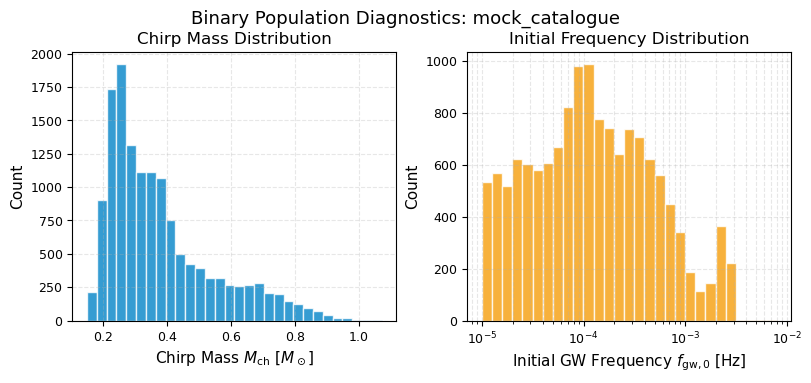

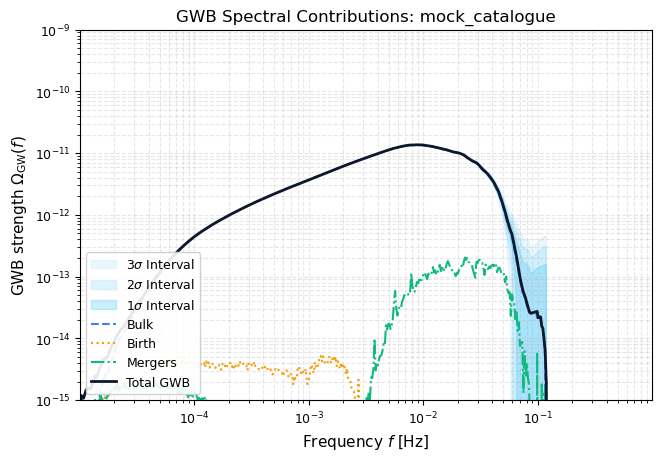

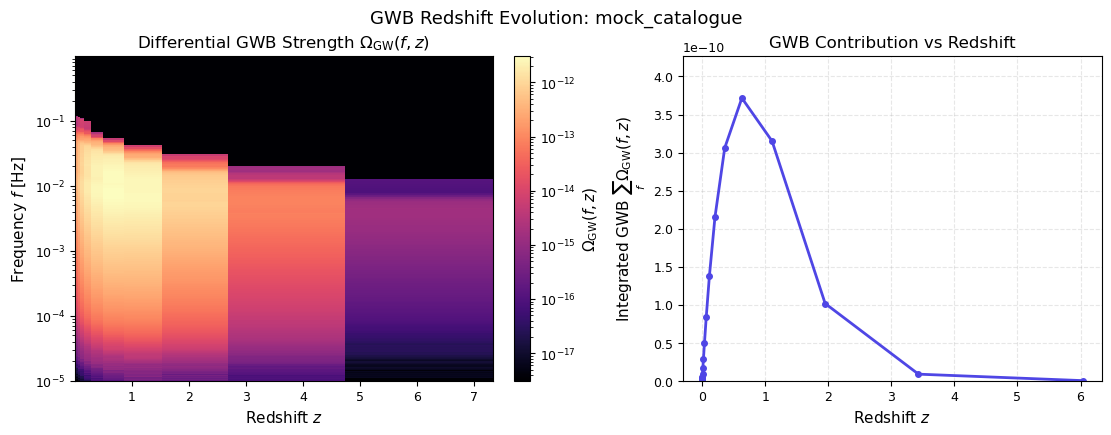

In [2]:
from lisaastrophysicalbackgrounds.gravitational_wave_background import GravitationalWaveBackground

# Initialize the GWB calculator with the configuration file
gwb = GravitationalWaveBackground('base_config.yaml')

# Run calculations (this JIT-compiles JAX kernels on the first run)
gwb.calculate_GWB()

frequencies = gwb.f_vals
omega_gw = gwb.omega_f
num_sources = gwb.N_sources_f

print(f"Calculated GWB for {len(frequencies)} frequency bins.")
print(f"Max GWB strength: {omega_gw.max():.2e} at {frequencies[omega_gw.argmax()]:.2e} Hz")

## 3. Visualize Diagnostics & GWB Evolution

We display the diagnostic plots generated by the pipeline directly inside the notebook. (These are saved automatically at the end of the simulation since `save_diagnostics: True` is enabled in `base_config.yaml`).

=== 1. Binary Population Diagnostics ===


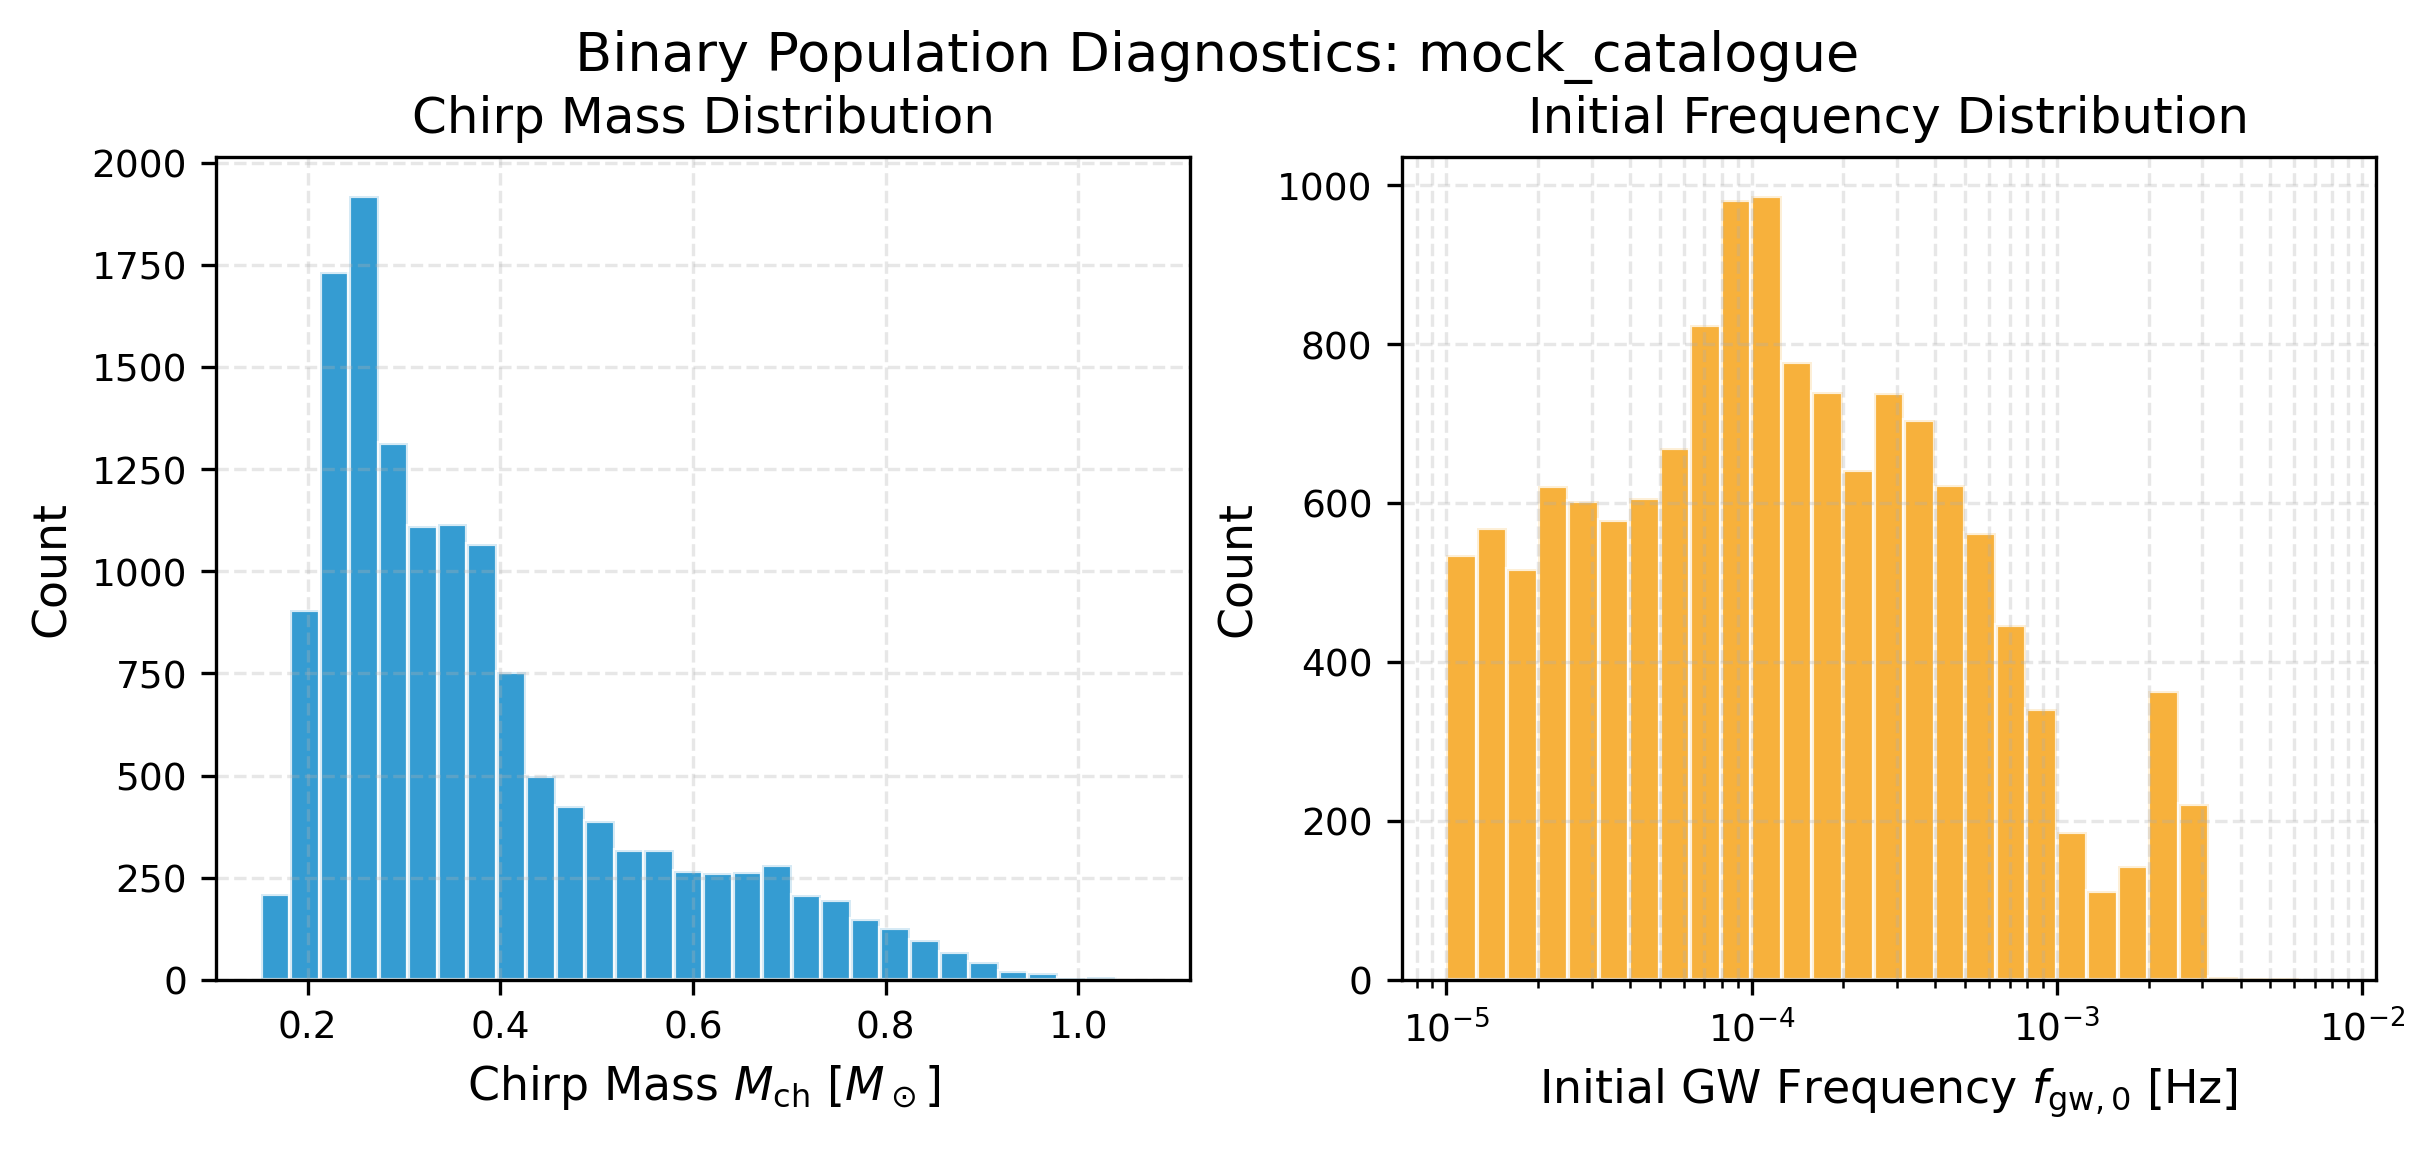


=== 2. GWB Component Breakdown ===


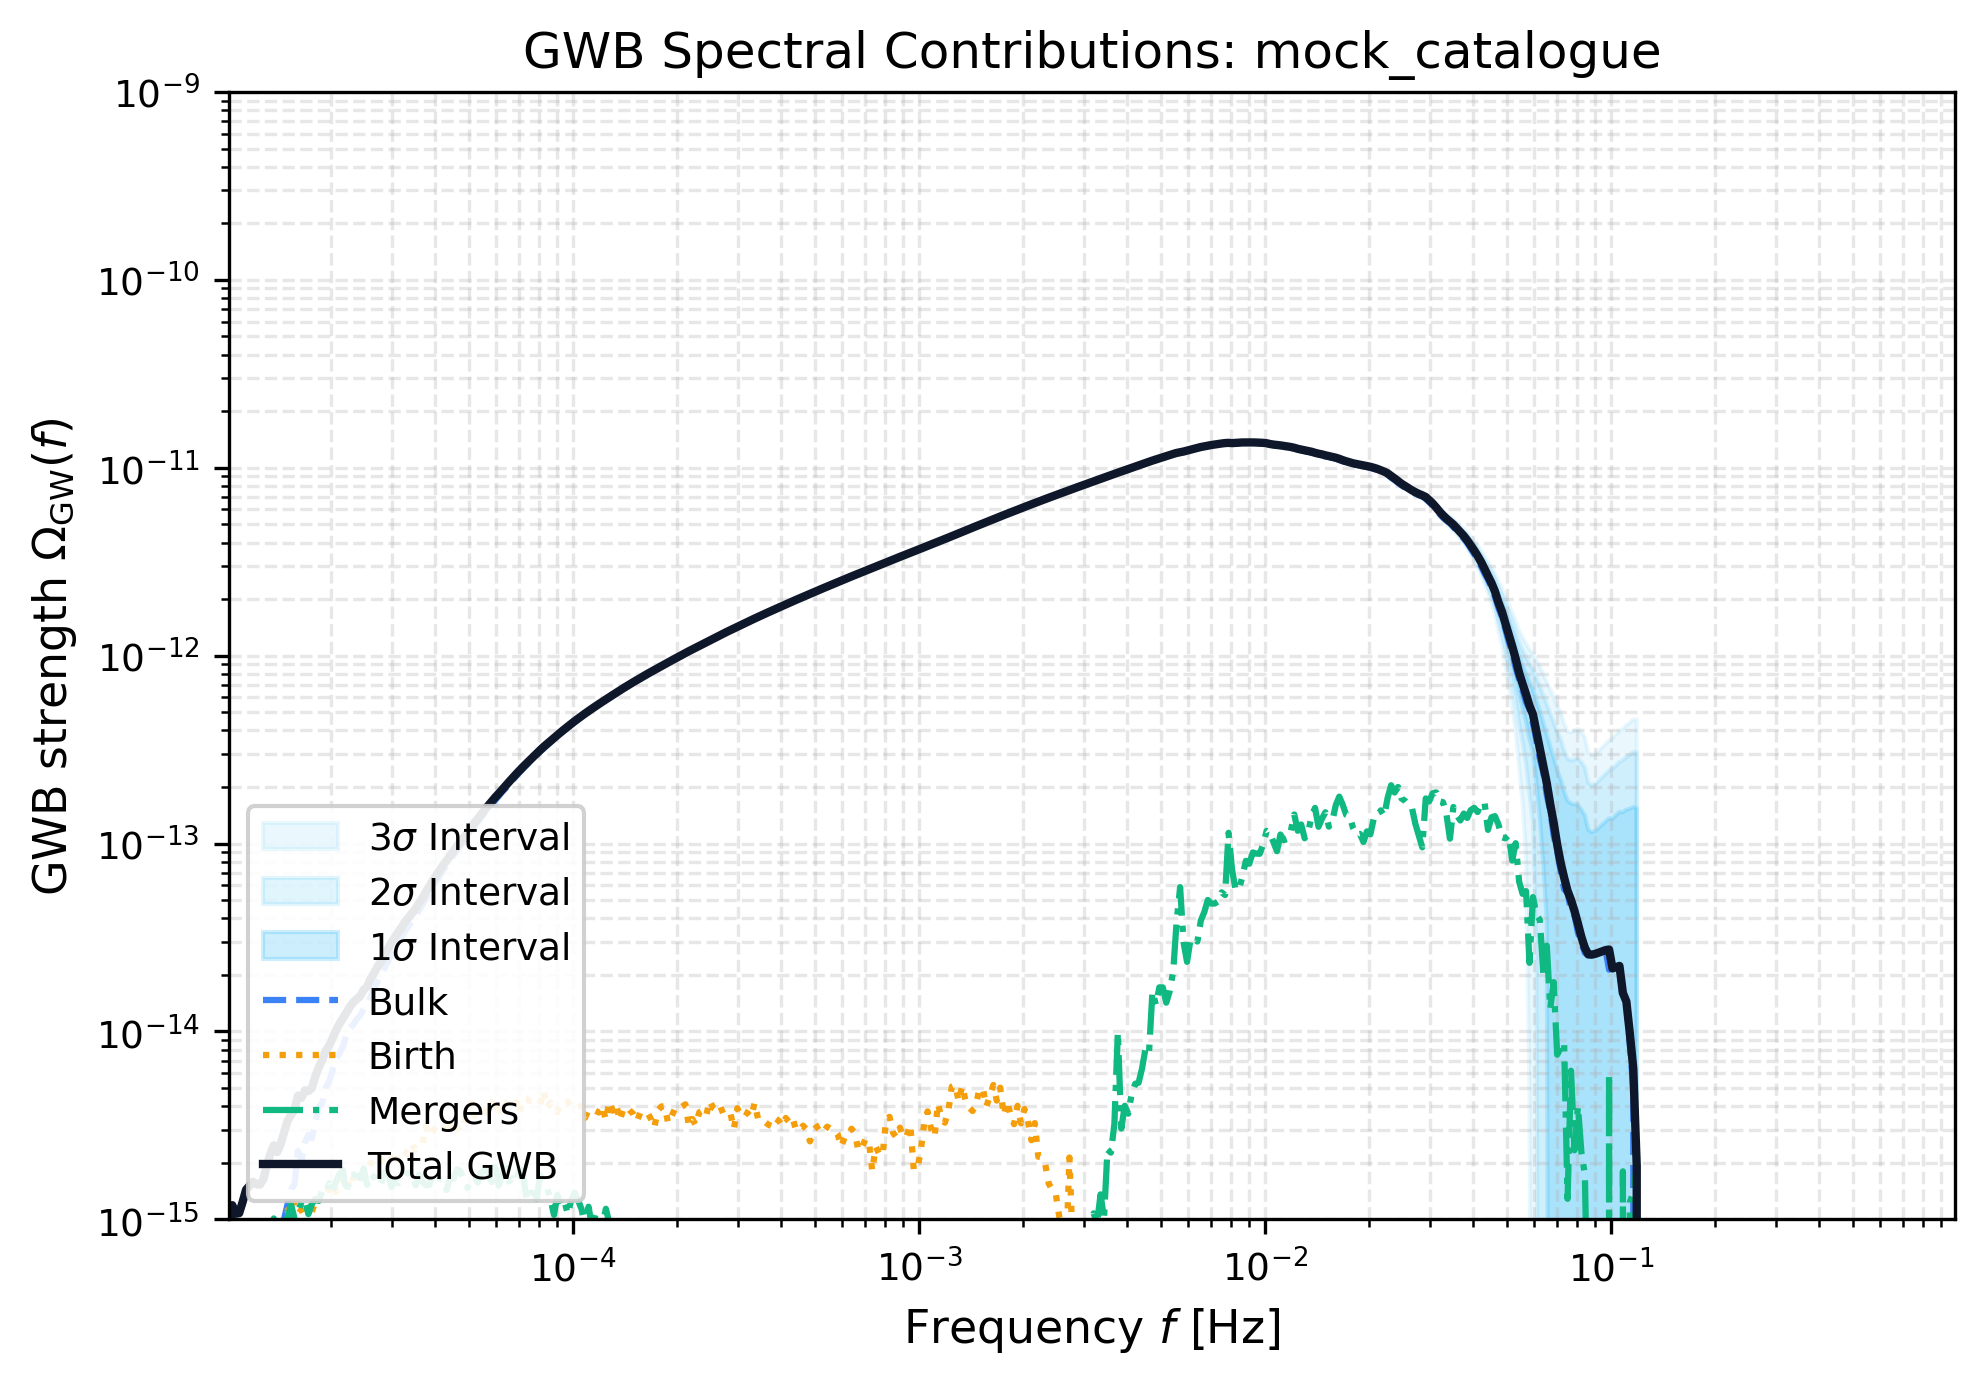


=== 3. GWB Redshift Evolution ===


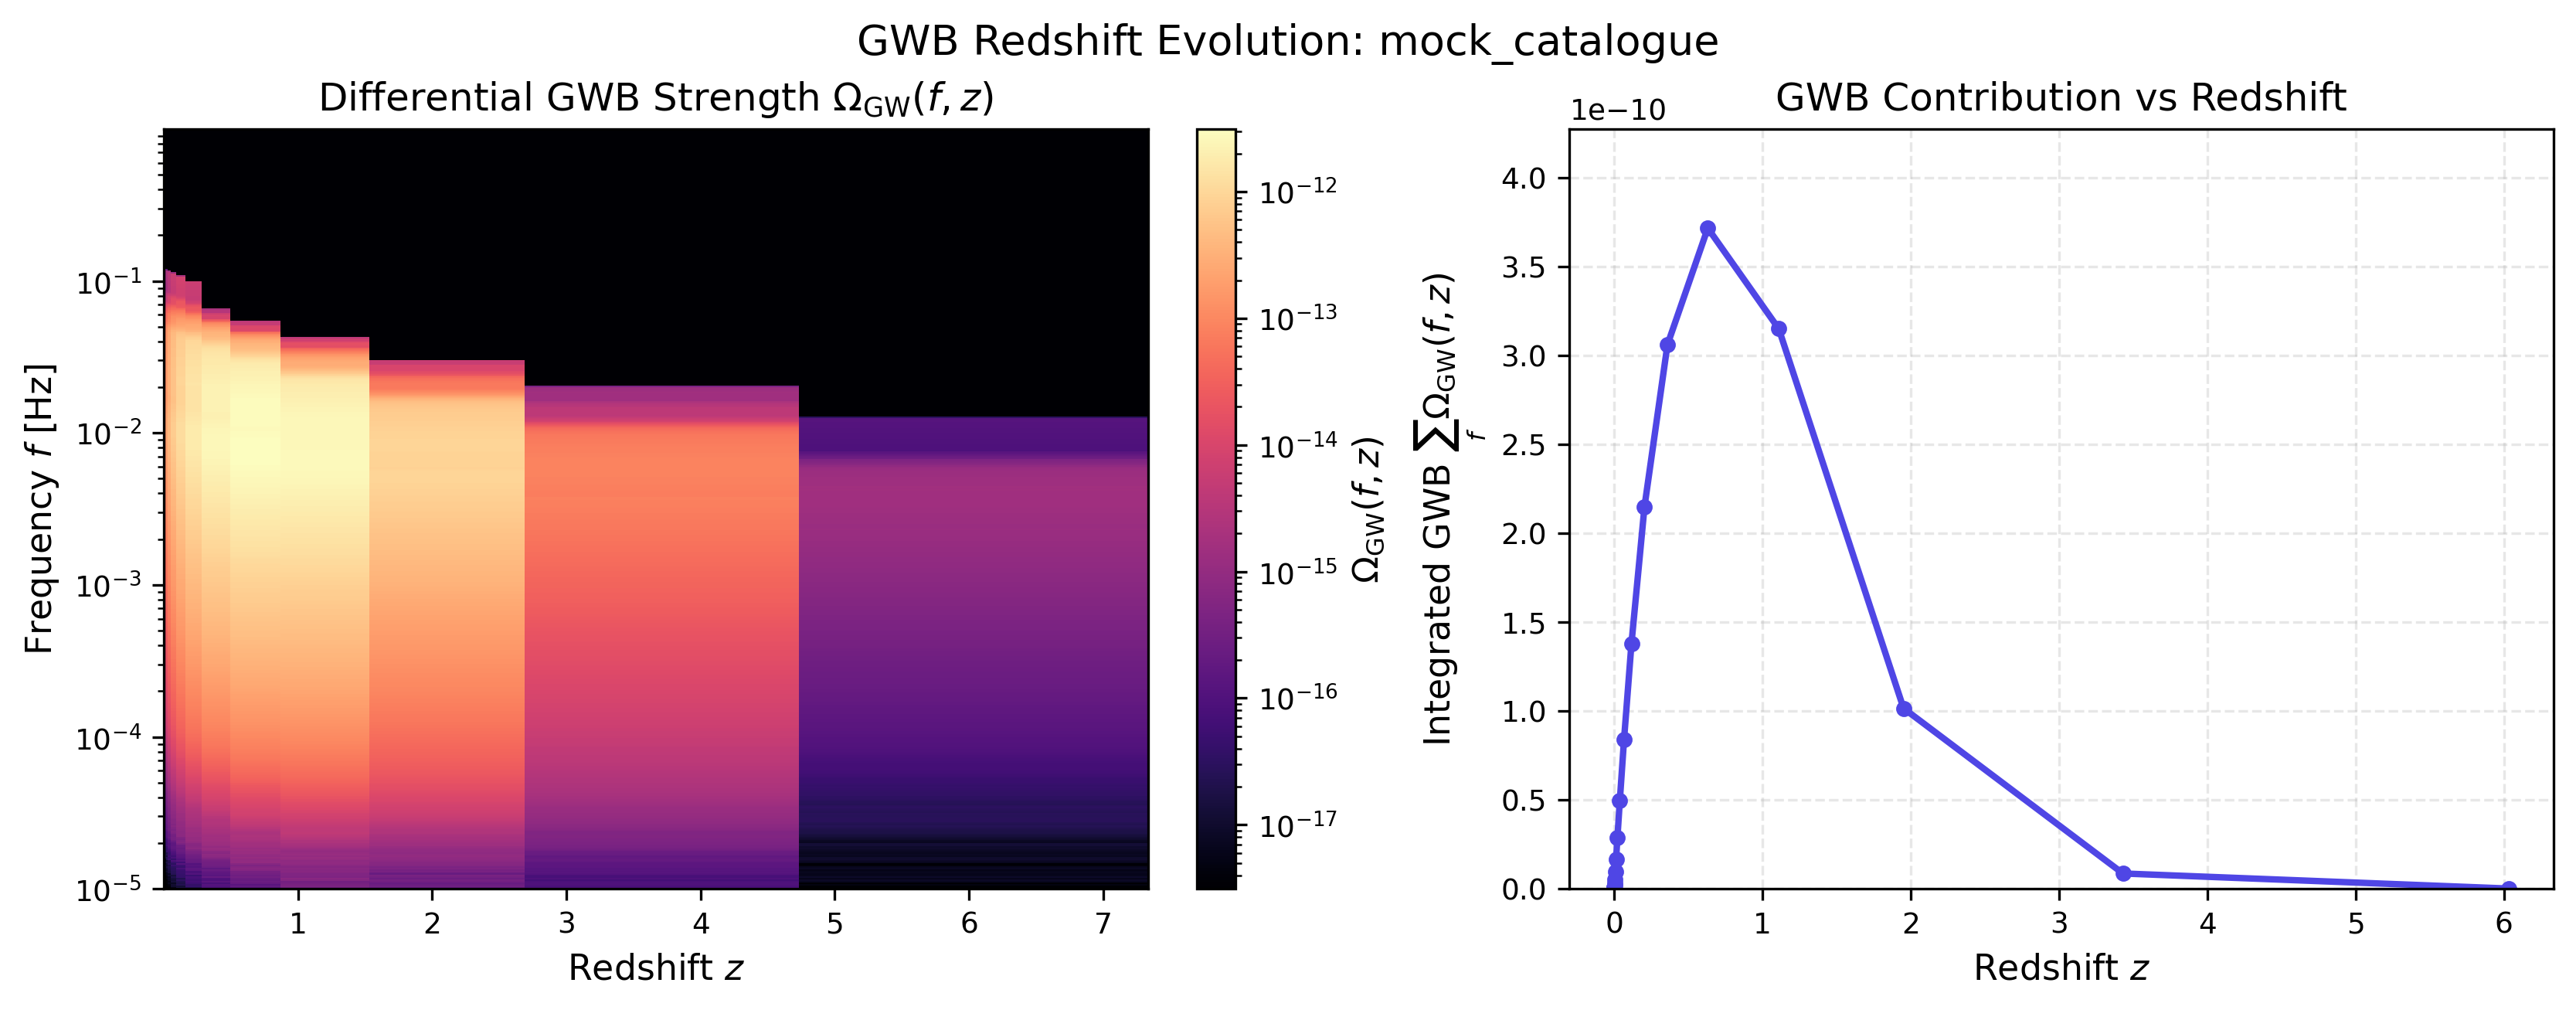

In [3]:
from IPython.display import Image, display

results_dir = os.path.join(repo_dir, "results")
pop_name = gwb.config["population"]["population_name"]
sfh_name = gwb.config["SFH"]["SFH_name"]

pop_plot_path = os.path.join(results_dir, f"diagnostic_population_{pop_name}.png")
spec_plot_path = os.path.join(results_dir, f"diagnostic_GWB_spectrum_{pop_name}_with_{sfh_name}.png")
redshift_plot_path = os.path.join(results_dir, f"diagnostic_GWB_redshift_{pop_name}.png")

print("=== 1. Binary Population Diagnostics ===")
display(Image(filename=pop_plot_path))

print("\n=== 2. GWB Component Breakdown ===")
display(Image(filename=spec_plot_path))

print("\n=== 3. GWB Redshift Evolution ===")
display(Image(filename=redshift_plot_path))

In [ ]:
python -c "import torch; print('CUDA可用状态:', torch.cuda.is_available()); print('显卡型号:', torch.cuda.get_device_name(0) if torch.cuda.is_available() else '检测不到')"